# 📈 Data-Driven Investment Intelligence Using NIFTY-50 Market Data
### An End-to-End AI-Powered Investment Platform

Name: **Tushar(23321031),  Sumit Kulhari(23118075)**

**Problem Statement:** Build an intelligent investment intelligence platform that transforms  
historical NIFTY-50 market data into actionable insights — covering stock prediction,  
portfolio construction, and risk assessment.

**Dataset:** [NIFTY-50 Stock Market Data (Kaggle)](https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data/data)

---
**Notebook Structure:**
1. Environment Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering (Technical Indicators)
4. Stock Predictor Engine (ML + Deep Learning)
5. Portfolio Construction Module
6. Risk Assessment Module
7. Explainability (SHAP)
8. Summary & Key Insights


## 📦 Section 1: Environment Setup & Data Loading

### Cell 1.1 — Install & Import Libraries
We import all necessary libraries upfront:
- **pandas / numpy**: Data manipulation and numerical computation
- **matplotlib / seaborn / plotly**: Visualizations (static + interactive)
- **scikit-learn**: ML models, preprocessing, evaluation
- **xgboost**: Gradient boosted trees for price direction prediction
- **tensorflow/keras**: LSTM deep learning model for time-series forecasting
- **PyPortfolioOpt**: Modern Portfolio Theory for portfolio optimization
- **shap**: Explainability of ML model predictions


In [ ]:
# Install required libraries (run once — uncomment and run if not already installed)
!pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost
!pip install tensorflow PyPortfolioOpt shap ta tqdm

import warnings
warnings.filterwarnings('ignore')

import os, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report)

import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from pypfopt import EfficientFrontier, risk_models, expected_returns

import shap
import ta

print("All libraries imported successfully!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 8.0 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=55fe8256053067aa57eceb7424d263c419d438dbf648e7f266946349fedfd61c
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta
All libraries imported successfully!


### Cell 1.2 — Load the Dataset
The NIFTY-50 dataset from Kaggle contains:
- **Individual stock CSVs** for each company (e.g., `RELIANCE.csv`, `TCS.csv`)
- **metadata.csv**: company name, sector, industry

We load all stock CSVs, add a `Symbol` column, and concatenate into one master DataFrame.  
This "long format" makes cross-stock analysis much easier later.


In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/nifty-50"

# Find all CSV files
csv_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print(f"Found {len(csv_files)} CSV files")

# Load metadata
metadata_file = [f for f in csv_files if "metadata" in f.lower()][0]
metadata = pd.read_csv(metadata_file)

# Load stock files
stock_dfs = []

for file in csv_files:
    if "metadata" in file.lower():
        continue

    try:
        df = pd.read_csv(file)
        stock_dfs.append(df)
    except Exception as e:
        print(f"Error loading {file}: {e}")

combined_df = pd.concat(stock_dfs, ignore_index=True)

print("Shape:", combined_df.shape)
print("Columns:", combined_df.columns.tolist())
combined_df.head()


Mounted at /content/drive
Found 52 CSV files
Shape: (470384, 15)
Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,UTIBANK,EQ,24.70,26.7,26.70,26.70,26.7,26.70,26.70,112100,2.993070e+11,NaN,NaN,NaN
1,2000-01-04,UTIBANK,EQ,26.70,27.0,28.70,26.50,27.0,26.85,27.24,234500,6.387275e+11,NaN,NaN,NaN
2,2000-01-05,UTIBANK,EQ,26.85,26.0,27.75,25.50,26.4,26.30,26.24,170100,4.462980e+11,NaN,NaN,NaN
3,2000-01-06,UTIBANK,EQ,26.30,25.8,27.00,25.80,25.9,25.95,26.27,102100,2.681730e+11,NaN,NaN,NaN
4,2000-01-07,UTIBANK,EQ,25.95,25.0,26.00,24.25,25.0,24.80,25.04,62600,1.567220e+11,NaN,NaN,NaN


### Cell 1.3 — Initial Data Inspection & Cleaning
Before any analysis, we check for:
- **Missing values**: Some companies may have gaps (trading halts, listing dates)
- **Data types**: Dates must be `datetime`, prices `float`
- **Duplicates**: Duplicate (Date, Symbol) pairs must be removed

We also standardize column names to lowercase for convenience.


In [ ]:
df = combined_df.copy()
# Standardize column names to lowercase for easier access
df.columns = df.columns.str.lower()

# ── Verify data types ────────────────────────────────────────────────────────
print("Column dtypes:")
print(df.dtypes)

# ── Missing values ────────────────────────────────────────────────────────────
print("\nMissing values per column:")
print(df.isnull().sum())

# ── Drop rows missing OHLCV (cannot impute price data meaningfully) ────────────
df.dropna(subset=['open', 'high', 'low', 'close', 'volume'], inplace=True)

# ── Remove duplicates (same stock, same date) ─────────────────────────────────
dupes = df.duplicated(subset=['symbol', 'date']).sum()
print(f"\nDuplicate (symbol, date) rows removed: {dupes}")
df.drop_duplicates(subset=['symbol', 'date'], inplace=True)

# ── Ensure correct dtypes ─────────────────────────────────────────────────────
df['date']   = pd.to_datetime(df['date'])
for col in ['open', 'high', 'low', 'close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce').fillna(0)

df.sort_values(['symbol', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nClean dataset: {df.shape[0]:,} rows | {df['symbol'].nunique()} stocks")
print(f"Columns: {list(df.columns)}")
df.describe()

Column dtypes:
date                   object
symbol                 object
series                 object
prev close            float64
open                  float64
high                  float64
low                   float64
last                  float64
close                 float64
vwap                  float64
volume                 object
turnover              float64
trades                float64
deliverable volume    float64
%deliverble           float64
dtype: object

Missing values per column:
date                       0
symbol                     0
series                     0
prev close                 0
open                       0
high                       0
low                        0
last                       0
close                      0
vwap                       0
volume                     0
turnover                   0
trades                229696
deliverable volume     32154
%deliverble            32154
dtype: int64

Duplicate (symbol, date) rows removed: 23519

,date,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble
count,235192,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.00000,2.351920e+05,2.351920e+05,1.203440e+05,2.191150e+05,219115.000000
mean,2011-05-22 13:18:08.975815424,1266.196349,1267.759708,1286.581440,1247.488465,1266.388302,1266.554351,1267.13230,3.045903e+06,1.610138e+14,6.196427e+04,1.315098e+06,0.502997
min,2000-01-03 00:00:00,0.000000,8.500000,9.750000,8.500000,9.100000,9.150000,9.21000,3.000000e+00,1.047000e+07,1.100000e+01,5.000000e+00,0.023600
25%,2006-07-03 00:00:00,274.300000,275.000000,279.500000,269.600000,274.400000,274.350000,274.69750,2.190095e+05,1.612816e+13,2.183400e+04,1.253830e+05,0.364700
50%,2011-08-19 00:00:00,566.500000,567.025000,576.900000,556.500000,567.000000,566.700000,566.94000,1.010938e+06,6.832603e+13,4.406800e+04,5.017560e+05,0.511000
75%,2016-06-24 00:00:00,1242.200000,1243.312500,1263.000000,1221.650000,1242.900000,1242.400000,1242.66250,3.019851e+06,1.863835e+14,7.893550e+04,1.452233e+06,0.638400
max,2021-04-30 00:00:00,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.24000,4.810589e+08,3.564334e+16,1.643015e+06,2.325307e+08,1.000000
std,NaN,2581.370320,2585.259609,2619.649216,2546.621396,2581.392543,2582.140942,2582.69998,7.333981e+06,3.298085e+14,6.866457e+04,2.831670e+06,0.190019


---
## 🔍 Section 2: Exploratory Data Analysis (EDA)

### Cell 2.1 — Market-wide Price Overview
We plot the **normalized close price** of all 50 stocks on one chart.  
Normalizing (dividing each series by its first value) lets us compare  
growth trajectories regardless of absolute price levels.

Key things to observe: which sectors led growth, and major market crashes  
(e.g., 2008 Global Financial Crisis, 2020 COVID crash).


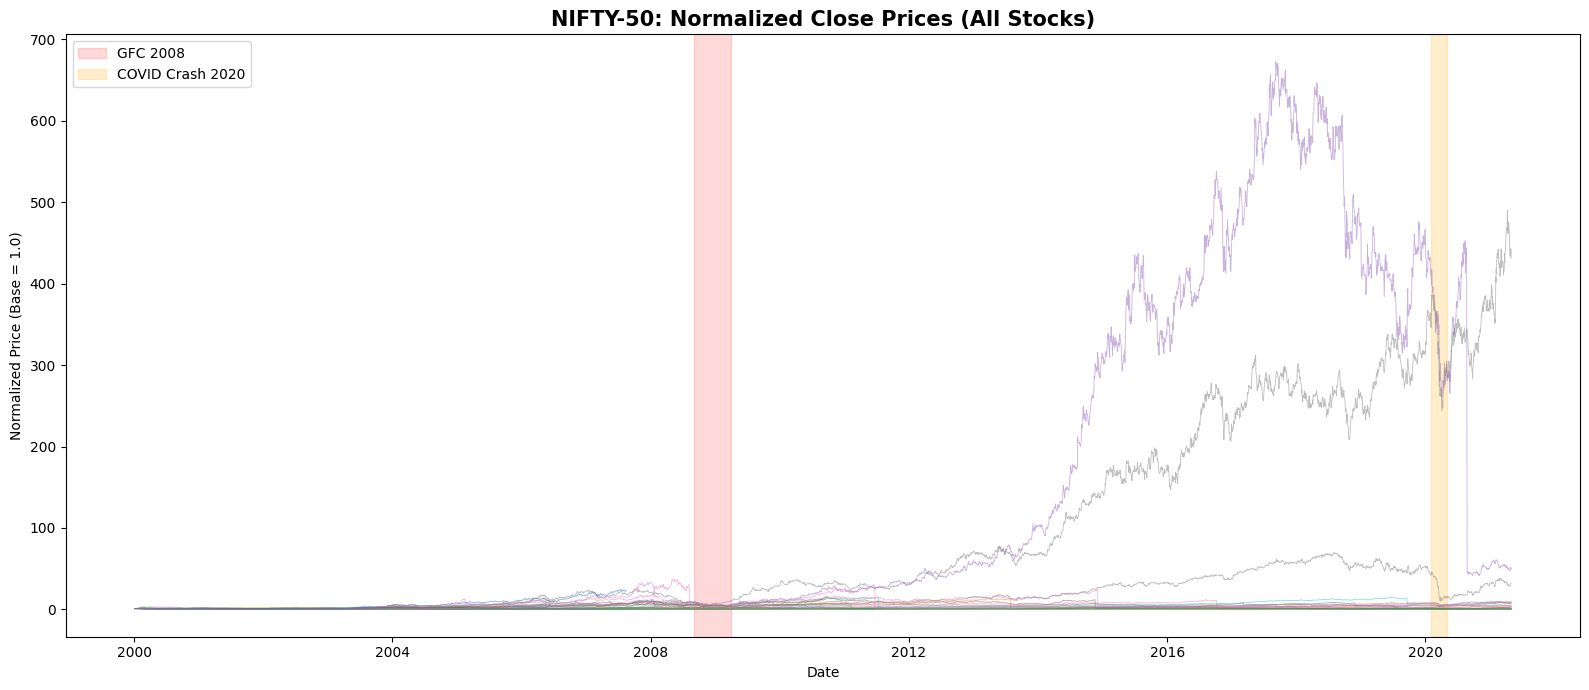

📌 Observation: Notice the sharp drops during 2008 (GFC) and March 2020 (COVID).


In [ ]:
# Pivot to wide format: rows=dates, columns=stock symbols
price_wide = df.pivot_table(index='date', columns='symbol', values='close')

# Normalize: each stock starts at 1.0 (makes comparisons fair)
price_norm = price_wide.div(price_wide.iloc[0])

fig, ax = plt.subplots(figsize=(16, 7))
for col in price_norm.columns:
    ax.plot(price_norm.index, price_norm[col], linewidth=0.6, alpha=0.5)

ax.set_title("NIFTY-50: Normalized Close Prices (All Stocks)", fontsize=15, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 1.0)")
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-31'),
           color='red', alpha=0.15, label='GFC 2008')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-30'),
           color='orange', alpha=0.2, label='COVID Crash 2020')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig("normalized_prices.png", dpi=150)
plt.show()
print("📌 Observation: Notice the sharp drops during 2008 (GFC) and March 2020 (COVID).")


### Cell 2.2 — Sector-wise Performance Analysis
We group stocks by sector and compute **cumulative returns** per sector.  
This tells us which sectors have been the best long-term performers.

**Return formula:** `cumulative_return = (last_price / first_price - 1) × 100`


⚠️  Sector column not found. Showing top 15 stocks by cumulative return instead.


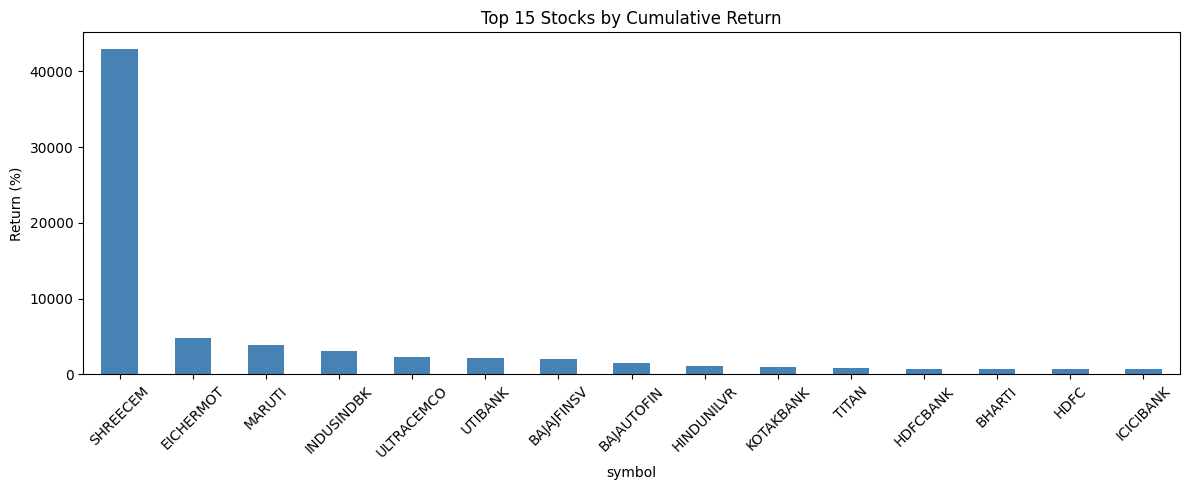

In [ ]:
if 'industry' in df.columns:
    # Compute cumulative return per stock
    def cumulative_return(series):
        series = series.dropna()
        if len(series) < 2 or series.iloc[0] == 0:
            return np.nan
        return (series.iloc[-1] / series.iloc[0] - 1) * 100

    returns_by_stock = (df.groupby('symbol')['close']
                          .apply(cumulative_return)
                          .reset_index(name='cumulative_return_%'))

    # Merge with sector info
    sector_map = df[['symbol', 'industry']].drop_duplicates()
    returns_by_stock = returns_by_stock.merge(sector_map, on='symbol', how='left')

    # Average cumulative return per sector
    sector_perf = (returns_by_stock.groupby('industry')['cumulative_return_%']
                                   .mean()
                                   .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in sector_perf.values]
    sector_perf.plot(kind='barh', ax=ax, color=colors)
    ax.set_title("Average Cumulative Return by Sector (2000–2021)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Cumulative Return (%)")
    ax.axvline(0, color='black', linewidth=0.8)
    for i, v in enumerate(sector_perf.values):
        ax.text(v + 50, i, f"{v:.0f}%", va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig("sector_returns.png", dpi=150)
    plt.show()
else:
    print("⚠️  Sector column not found. Showing top 15 stocks by cumulative return instead.")
    returns_per_stock = df.groupby('symbol')['close'].apply(
        lambda s: (s.iloc[-1]/s.iloc[0] - 1)*100 if len(s) > 1 else np.nan
    ).sort_values(ascending=False).head(15)
    returns_per_stock.plot(kind='bar', figsize=(12, 5), color='steelblue')
    plt.title("Top 15 Stocks by Cumulative Return")
    plt.ylabel("Return (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Cell 2.3 — Daily Returns Distribution & Volatility
**Daily Return** = `(Today's Close - Yesterday's Close) / Yesterday's Close`

We analyze:
- Distribution shape (are returns normally distributed?)
- Skewness / fat tails (extreme events)
- Which stocks are most volatile (risky)?


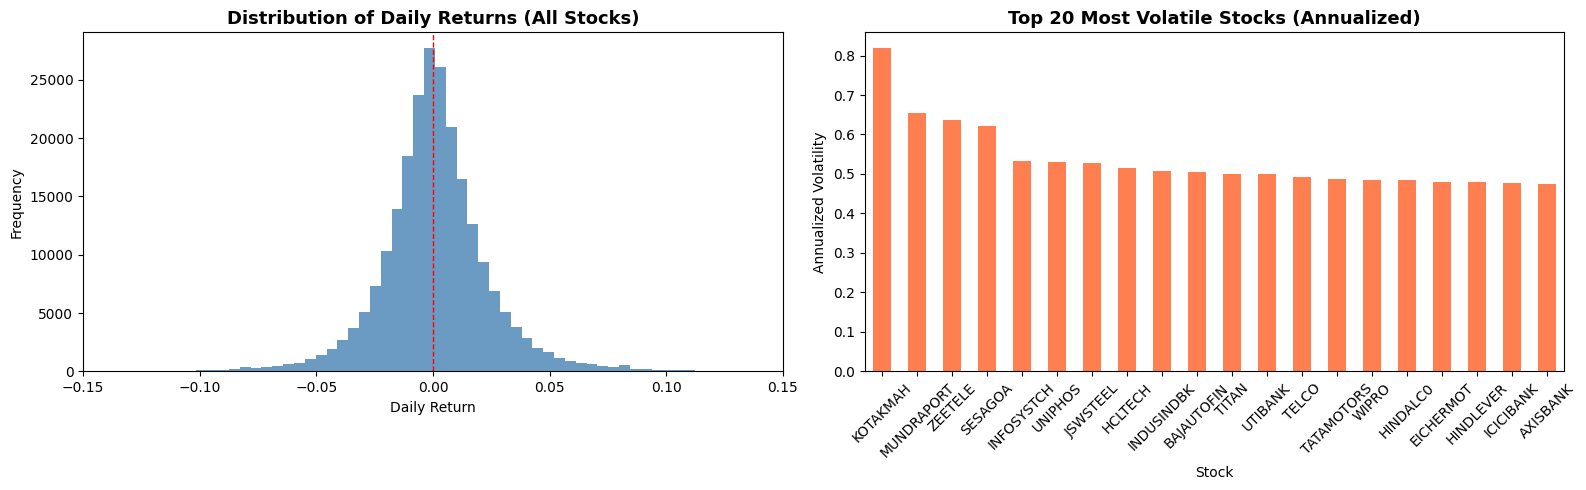

📌 Mean daily return : 0.0688%
📌 Std of daily returns: 2.7252%
📌 Skewness: -4.489  (negative = left tail risk)
📌 Kurtosis: 132.600  (>3 means fat tails — extreme events are common)


In [ ]:
# Compute daily returns for each stock
df.sort_values(['symbol', 'date'], inplace=True)
df['daily_return'] = df.groupby('symbol')['close'].pct_change()

# Overall return distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of all daily returns
axes[0].hist(df['daily_return'].dropna(), bins=300, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlim(-0.15, 0.15)
axes[0].set_title("Distribution of Daily Returns (All Stocks)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Frequency")
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

# Annualized volatility per stock (std of daily returns × √252)
vol = df.groupby('symbol')['daily_return'].std() * np.sqrt(252)
vol.sort_values(ascending=False).head(20).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Top 20 Most Volatile Stocks (Annualized)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Stock")
axes[1].set_ylabel("Annualized Volatility")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("return_distributions.png", dpi=150)
plt.show()

print(f"📌 Mean daily return : {df['daily_return'].mean():.4%}")
print(f"📌 Std of daily returns: {df['daily_return'].std():.4%}")
print(f"📌 Skewness: {df['daily_return'].skew():.3f}  (negative = left tail risk)")
print(f"📌 Kurtosis: {df['daily_return'].kurt():.3f}  (>3 means fat tails — extreme events are common)")


### Cell 2.4 — Correlation Heatmap
Stocks that are **highly correlated** tend to move together — holding  
many of them in a portfolio doesn't reduce risk much.

We use the **daily returns correlation matrix** (not price, as prices  
share a common upward trend which inflates correlations artificially).

Clusters in the heatmap reveal **sector groupings** — banking stocks  
tend to move together, IT stocks together, etc.


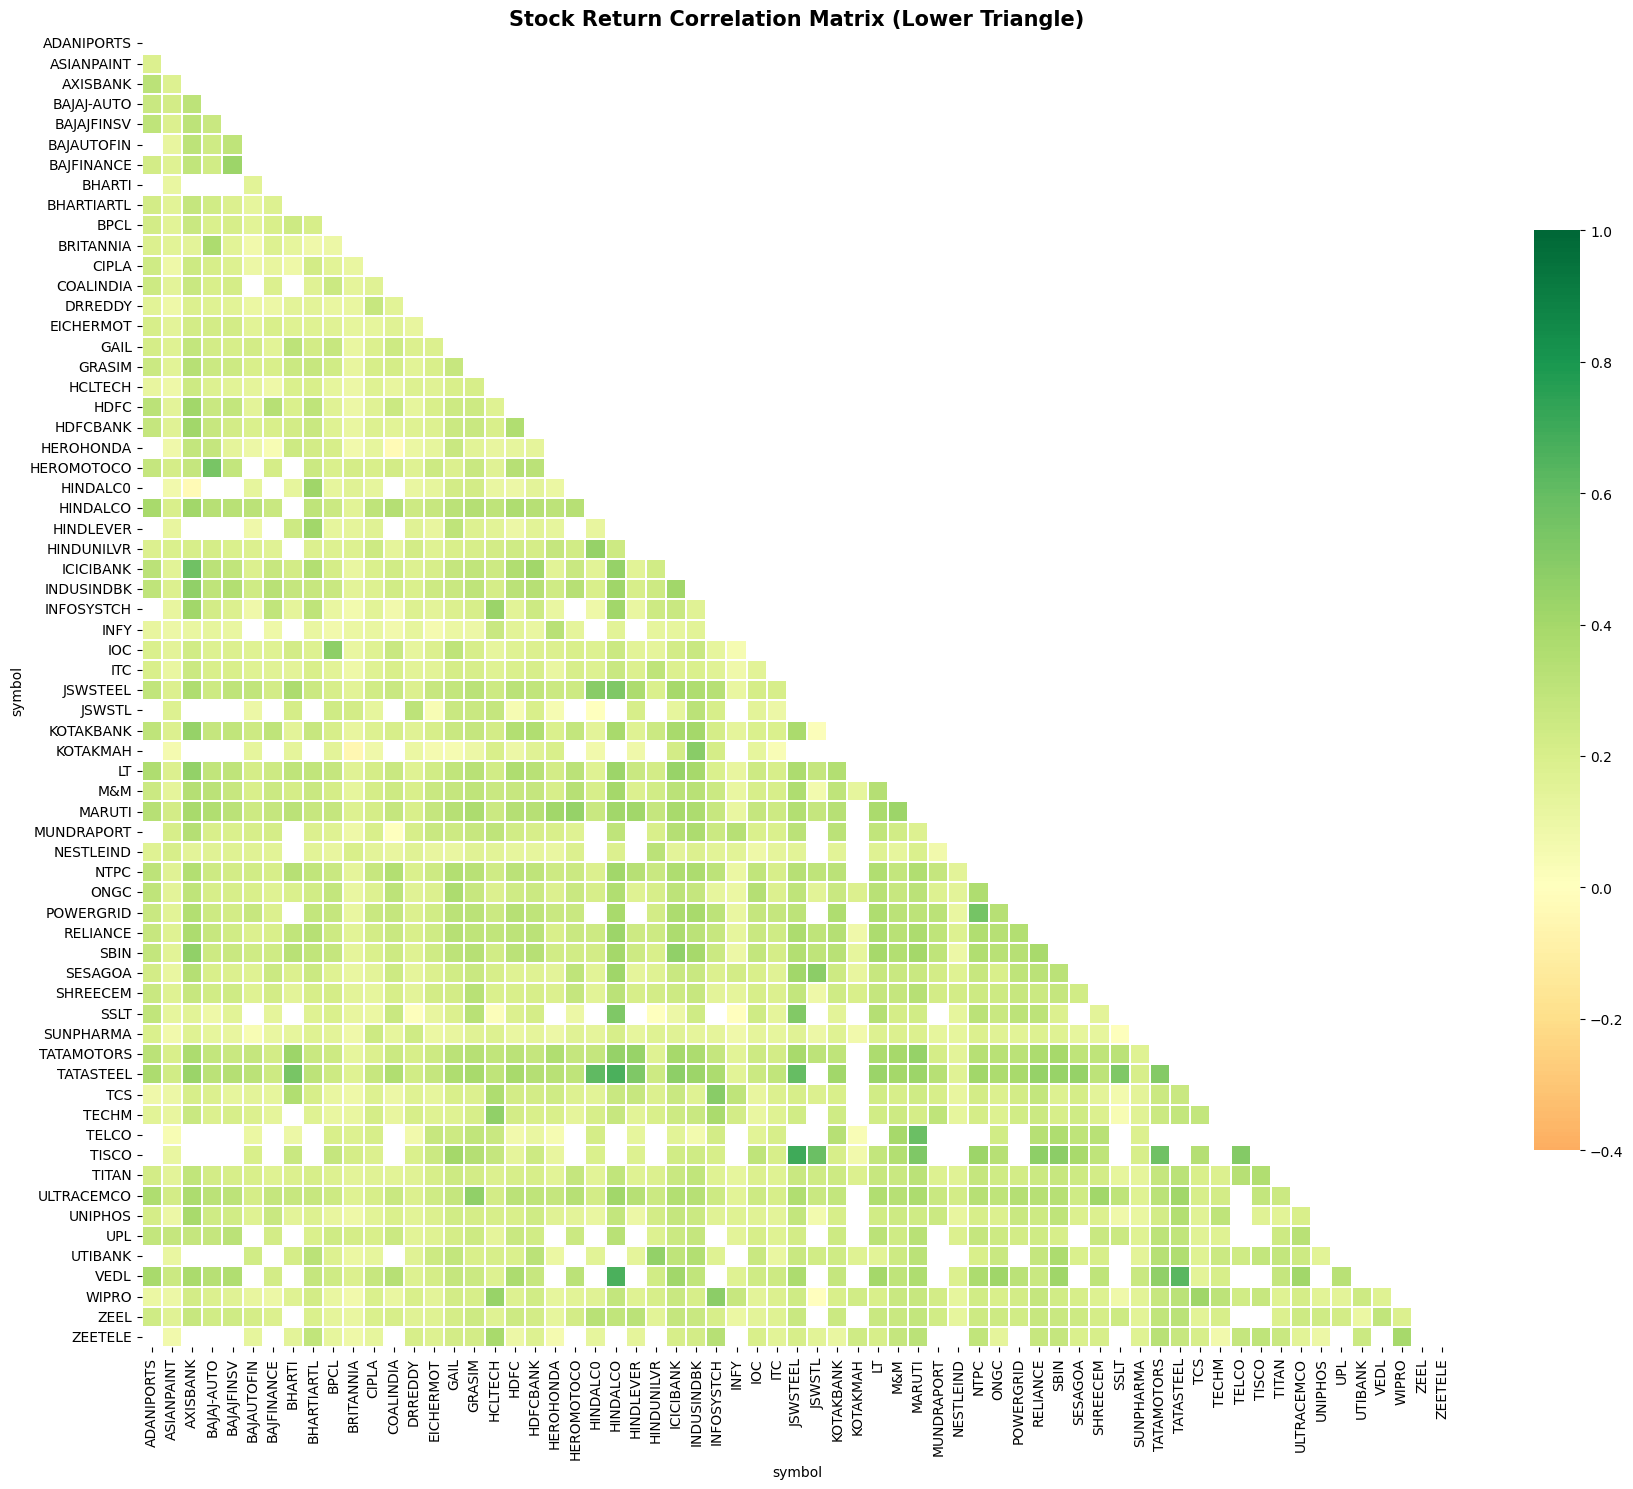

🔗 Top 10 Most Correlated Pairs:
  Stock_A    Stock_B  Correlation
    TISCO   JSWSTEEL     0.698824
TATASTEEL   HINDALCO     0.667409
     VEDL   HINDALCO     0.664223
     VEDL  TATASTEEL     0.624824
TATASTEEL   HINDALC0     0.609576
TATASTEEL   JSWSTEEL     0.598343
    TELCO     MARUTI     0.583863
    TISCO     JSWSTL     0.579934
ICICIBANK   AXISBANK     0.565713
    TISCO TATAMOTORS     0.562998

🔗 Top 5 Least Correlated (Diversification Candidates):
  Stock_A   Stock_B  Correlation
 KOTAKMAH BRITANNIA    -0.045134
HEROHONDA COALINDIA    -0.036332
 HINDALC0  AXISBANK    -0.028423
     SSLT      INFY    -0.004371
    WIPRO    JSWSTL    -0.001973


In [ ]:
# Build a returns matrix: rows=dates, columns=symbols
returns_wide = df.pivot_table(index='date', columns='symbol', values='daily_return')

# Correlation matrix of returns
corr_matrix = returns_wide.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle (redundant)
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            center=0, vmin=-0.4, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title("Stock Return Correlation Matrix (Lower Triangle)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

# Find top correlated pairs
# Rename the MultiIndex levels before resetting the index to avoid column name conflicts
corr_unstacked = corr_matrix.where(mask == False).stack().rename_axis(index=['Stock_A', 'Stock_B']).reset_index(name='Correlation')
corr_unstacked = corr_unstacked[corr_unstacked['Stock_A'] != corr_unstacked['Stock_B']]

print("🔗 Top 10 Most Correlated Pairs:")
print(corr_unstacked.nlargest(10, 'Correlation').to_string(index=False))
print("\n🔗 Top 5 Least Correlated (Diversification Candidates):")
print(corr_unstacked.nsmallest(5, 'Correlation').to_string(index=False))

---
## ⚙️ Section 3: Feature Engineering — Technical Indicators

### Cell 3.1 — Why Technical Indicators?
Raw OHLCV data doesn't capture patterns well for ML models.  
Technical indicators **transform** price/volume into features that capture:

| Indicator | What it captures |
|---|---|
| **SMA / EMA** | Trend direction and momentum |
| **RSI** | Overbought (>70) / Oversold (<30) conditions |
| **MACD** | Trend changes via two EMAs |
| **Bollinger Bands** | Volatility — price outside bands = potential reversal |
| **ATR** | Average True Range — measures daily volatility |
| **OBV** | On-Balance Volume — confirms price moves with volume |

We compute these per stock using the `ta` (Technical Analysis) library.


In [ ]:
def add_technical_indicators(group):
    """
    Adds ~20 technical indicators to a single stock's DataFrame.
    Input: group = sub-DataFrame for one stock, sorted by date.
    """
    close = group['close']
    high  = group['high']
    low   = group['low']
    vol   = group['volume']

    # ── Trend Indicators ──────────────────────────────────────
    group['sma_20']  = ta.trend.sma_indicator(close, window=20)
    group['sma_50']  = ta.trend.sma_indicator(close, window=50)
    group['ema_12']  = ta.trend.ema_indicator(close, window=12)
    group['ema_26']  = ta.trend.ema_indicator(close, window=26)

    # MACD = EMA(12) - EMA(26); Signal = EMA(9) of MACD
    macd_obj = ta.trend.MACD(close)
    group['macd']        = macd_obj.macd()
    group['macd_signal'] = macd_obj.macd_signal()
    group['macd_hist']   = macd_obj.macd_diff()   # histogram

    # ── Momentum Indicators ───────────────────────────────────
    group['rsi_14'] = ta.momentum.RSIIndicator(close, window=14).rsi()
    group['stoch_k'] = ta.momentum.StochasticOscillator(high, low, close).stoch()
    group['stoch_d'] = ta.momentum.StochasticOscillator(high, low, close).stoch_signal()
    group['roc_10']  = ta.momentum.ROCIndicator(close, window=10).roc()  # Rate of Change

    # ── Volatility Indicators ─────────────────────────────────
    bb = ta.volatility.BollingerBands(close, window=20, window_dev=2)
    group['bb_upper']  = bb.bollinger_hband()
    group['bb_lower']  = bb.bollinger_lband()
    group['bb_width']  = bb.bollinger_wband()   # (upper-lower)/middle
    group['bb_pct']    = bb.bollinger_pband()   # where price sits in the band [0,1]
    group['atr_14']    = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range()

    # ── Volume Indicators ─────────────────────────────────────
    group['obv']       = ta.volume.OnBalanceVolumeIndicator(close, vol).on_balance_volume()
    group['vol_sma_20']= vol.rolling(20).mean()
    group['vol_ratio'] = vol / group['vol_sma_20']  # volume vs its average

    # ── Price-derived features ───────────────────────────────
    group['price_range_pct'] = (high - low) / close           # intraday range
    group['return_1d']  = close.pct_change(1)
    group['return_5d']  = close.pct_change(5)
    group['return_20d'] = close.pct_change(20)

    return group

print("⚙️  Computing technical indicators for all 50 stocks (may take ~1–2 min)...")
df = df.groupby('symbol', group_keys=False).apply(add_technical_indicators)
print(f"✅ Done! DataFrame now has {df.shape[1]} columns.")
df.head(3)


⚙️  Computing technical indicators for all 50 stocks (may take ~1–2 min)...
✅ Done! DataFrame now has 39 columns.


,date,symbol,series,prev close,open,high,low,last,close,vwap,...,bb_width,bb_pct,atr_14,obv,vol_sma_20,vol_ratio,price_range_pct,return_1d,return_5d,return_20d
0,2012-01-17,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.0,138.13,...,NaN,NaN,0.0,1636196,NaN,NaN,0.042857,NaN,NaN,NaN
1,2012-01-18,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.7,141.25,...,NaN,NaN,0.0,2526787,NaN,NaN,0.035992,0.012143,NaN,NaN
2,2012-01-19,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.4,146.72,...,NaN,NaN,0.0,3982864,NaN,NaN,0.049531,0.054340,NaN,NaN


### Cell 3.2 — Create Prediction Target
For classification (predicting price direction):  
**Target = 1** if tomorrow's close > today's close, else **0**.

For regression (predicting future price):  
**Target = next N-day close price** (or log return).

We create both targets so we can use them in different models.


In [ ]:
# Sort to make sure shift is correct
df.sort_values(['symbol', 'date'], inplace=True)

# ── Classification target: will price go UP tomorrow? ────────
df['target_direction'] = (
    df.groupby('symbol')['close']
      .shift(-1) > df['close']
).astype(int)

# ── Regression target: next-day close price ──────────────────
df['target_price_1d']  = df.groupby('symbol')['close'].shift(-1)
df['target_price_5d']  = df.groupby('symbol')['close'].shift(-5)

# ── Log return target (useful for LSTM) ──────────────────────
df['target_log_return'] = np.log(df.groupby('symbol')['close'].shift(-1) / df['close'])

print("Target value counts (direction):")
print(df['target_direction'].value_counts(normalize=True).round(3))
print("\n📌 Roughly 50/50 split — market direction is hard to predict!")
print(f"Total rows with valid targets: {df['target_direction'].notna().sum():,}")


Target value counts (direction):
target_direction
1    0.503
0    0.497
Name: proportion, dtype: float64

📌 Roughly 50/50 split — market direction is hard to predict!
Total rows with valid targets: 235,192


---
## 🤖 Section 4: Stock Predictor Engine

### Cell 4.1 — Choose a Stock & Prepare ML Dataset
We focus on **one stock** (e.g., TCS — India's largest IT company) to train  
and evaluate our models in detail. The same pipeline can be applied to any stock.

**Feature matrix X**: all technical indicators  
**Target y**: direction (up/down) for classification, or price for regression  

We use **TimeSeriesSplit** (not random split) to avoid data leakage —  
future data must never be used to train a model predicting the past.


In [ ]:
# ── Select stock to model ─────────────────────────────────────
STOCK = 'TCS'   # Change to any NIFTY-50 symbol

stock_df = df[df['symbol'] == STOCK].copy()
print(f"📊 {STOCK}: {len(stock_df)} trading days ({stock_df['date'].min().date()} → {stock_df['date'].max().date()})")

# ── Define feature columns ────────────────────────────────────
FEATURE_COLS = [
    'sma_20', 'sma_50', 'ema_12', 'ema_26',
    'macd', 'macd_signal', 'macd_hist',
    'rsi_14', 'stoch_k', 'stoch_d', 'roc_10',
    'bb_width', 'bb_pct', 'atr_14',
    'obv', 'vol_ratio',
    'price_range_pct', 'return_1d', 'return_5d', 'return_20d'
]

# Drop rows with NaN features or target (NaN comes from indicator warmup period)
model_df = stock_df[FEATURE_COLS + ['target_direction', 'target_price_1d', 'date']].dropna()
print(f"Rows after dropping NaN (indicator warmup): {len(model_df)}")

X = model_df[FEATURE_COLS].values
y_class = model_df['target_direction'].values   # for classification
y_reg   = model_df['target_price_1d'].values    # for regression

# ── Time-series aware train/test split (80% train, 20% test) ─
split_idx = int(len(model_df) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train_c, y_test_c = y_class[:split_idx], y_class[split_idx:]
y_train_r, y_test_r = y_reg[:split_idx],   y_reg[split_idx:]
dates_test = model_df['date'].iloc[split_idx:].values

print(f"\nTrain: {len(X_train)} samples | Test: {len(X_test)} samples")
print("⚠️  Using TimeSeriesSplit — no future data leaks into training set")


📊 TCS: 4139 trading days (2004-08-25 → 2021-04-30)
Rows after dropping NaN (indicator warmup): 4089

Train: 3271 samples | Test: 818 samples
⚠️  Using TimeSeriesSplit — no future data leaks into training set


### Cell 4.2 — Model 1: XGBoost Classifier (Direction Prediction)
XGBoost is a gradient-boosted decision tree algorithm — extremely effective  
for tabular/financial data. It:
- Handles non-linear relationships between features and target
- Is robust to outliers
- Provides feature importances (which indicators matter most?)

We predict: **Will the stock go up or down tomorrow?**  
Accuracy around 52–55% is considered good (market is near-random).


🎯 XGBoost Directional Accuracy: 52.32%
   (50% = random guessing; 55%+ = meaningful edge)

              precision    recall  f1-score   support

    Down (0)       0.50      0.61      0.55       390
      Up (1)       0.56      0.44      0.49       428

    accuracy                           0.52       818
   macro avg       0.53      0.53      0.52       818
weighted avg       0.53      0.52      0.52       818



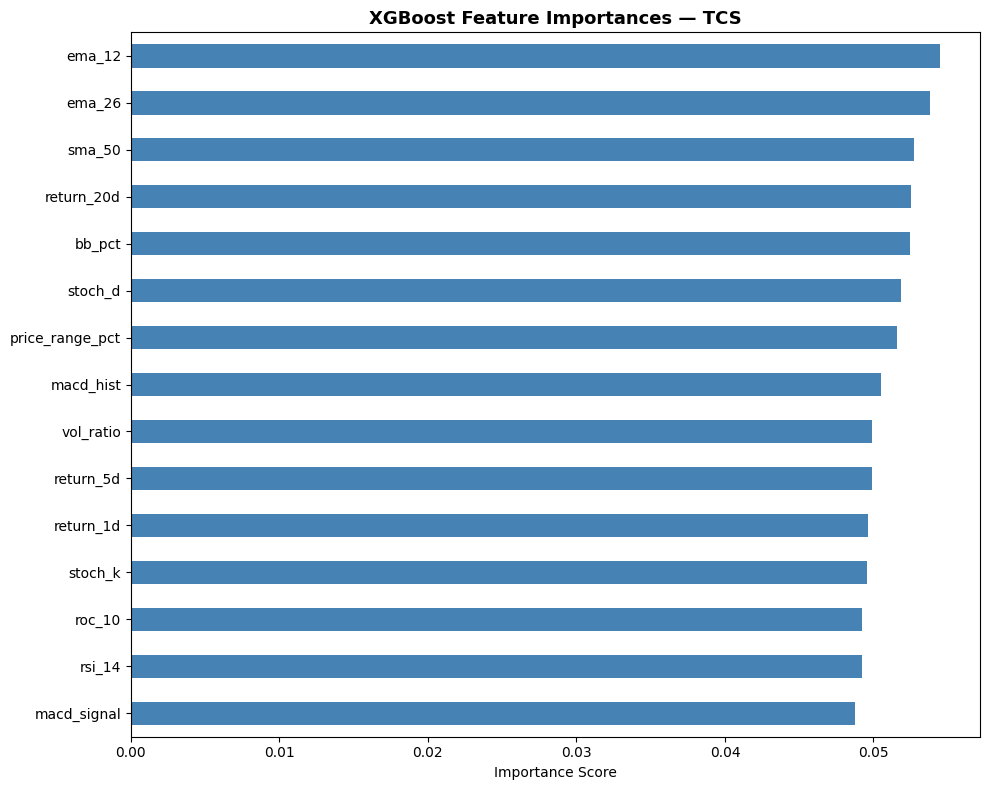

In [ ]:
# ── Scale features ───────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only (no leakage)
X_test_s  = scaler.transform(X_test)

# ── Train XGBoost ─────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train_s, y_train_c,
    eval_set=[(X_test_s, y_test_c)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test_s)
acc = accuracy_score(y_test_c, y_pred_xgb)

print(f"🎯 XGBoost Directional Accuracy: {acc:.2%}")
print(f"   (50% = random guessing; 55%+ = meaningful edge)\n")
print(classification_report(y_test_c, y_pred_xgb, target_names=['Down (0)', 'Up (1)']))

# ── Feature Importance ────────────────────────────────────────
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f"XGBoost Feature Importances — {STOCK}", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(f"xgb_feature_importance_{STOCK}.png", dpi=150)
plt.show()


### Cell 4.3 — Model 2: LSTM (Long Short-Term Memory) — Price Forecasting
LSTMs are a type of Recurrent Neural Network designed for sequential/time-series data.  
Unlike XGBoost (which sees each day independently), LSTM **remembers** patterns  
from the past N days (look-back window) to predict the next day's price.

**Architecture:**
- Input: sliding window of last 60 days of features
- 2 stacked LSTM layers (learn short and long-term patterns)
- Dropout layers (prevent overfitting)
- Dense output layer (predict next-day close price)


In [ ]:
# ── Prepare sequences for LSTM ───────────────────────────────
# LSTM needs 3D input: (samples, timesteps, features)
LOOK_BACK = 60   # use past 60 trading days (~3 months)

# Scale target price for LSTM
price_scaler = MinMaxScaler()
y_scaled_all = price_scaler.fit_transform(model_df[['target_price_1d']].ffill())

# Scale features
feat_scaler = MinMaxScaler()
X_scaled_all = feat_scaler.fit_transform(model_df[FEATURE_COLS].fillna(0))

def create_sequences(X, y, look_back):
    Xs, ys = [], []
    for i in range(look_back, len(X)):
        Xs.append(X[i - look_back:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled_all, y_scaled_all.flatten(), LOOK_BACK)

# Train/test split (preserve time order)
split = int(len(X_seq) * 0.80)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

# ── Build LSTM model ─────────────────────────────────────────
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, len(FEATURE_COLS))),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)
]

history = lstm_model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_te, y_te),
    callbacks=callbacks,
    verbose=1
)
print("\n✅ LSTM training complete!")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,977 (136.63 KB)

 Trainable params: 34,849 (136.13 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 0.0282 - mae: 0.1241 - val_loss: 0.0905 - val_mae: 0.2733 - learning_rate: 0.0010
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0084 - mae: 0.0723 - val_loss: 0.0604 - val_mae: 0.2278 - learning_rate: 0.0010
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.0054 - mae: 0.0573 - val_loss: 0.0149 - val_mae: 0.0907 - learning_rate: 0.0010
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0044 - mae: 0.0517 - val_loss: 0.0080 - val_mae: 0.0609 - learning_rate: 0.0010
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0032 - mae: 0.0430 - val_loss: 0.0194 - val_mae: 0.0823 - learning_rate: 0.0010
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0028 - mae: 0.0399 - val_loss: 0.0741 - val_mae: 0.1462 - learning_rate: 0.0010
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0029 - mae: 0.0400 - val_loss: 0.0121 - val_mae: 0.0941 - learning_rate: 0.001

### Cell 4.4 — Evaluate LSTM & Plot Predictions
We evaluate regression performance using:
- **MAE** (Mean Absolute Error): average ₹ error per day
- **RMSE** (Root Mean Squared Error): penalizes large errors more
- **R²**: how much variance is explained (1.0 = perfect)
- **Directional Accuracy**: did the model predict the right direction?

We also plot actual vs predicted prices — a common and impactful  
visualization for portfolio managers.


📊 LSTM Evaluation — TCS
   MAE : ₹161.13  (average absolute price error)
   RMSE: ₹240.21
   R²  : 0.7442  (1.0 = perfect fit)
   Directional Accuracy: 48.57%


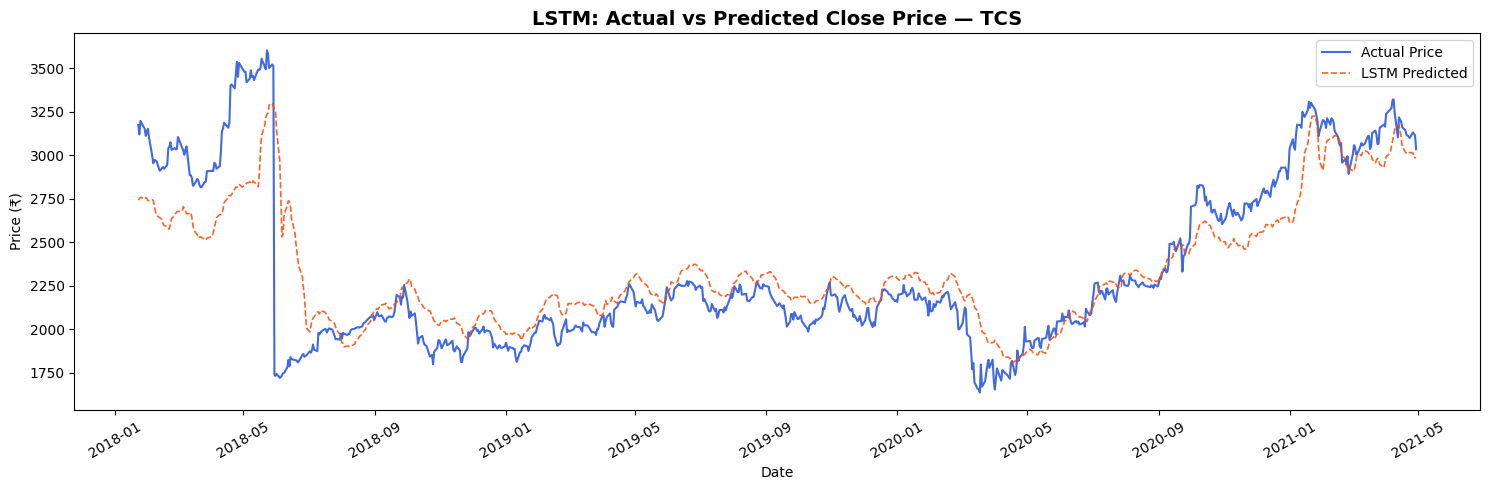

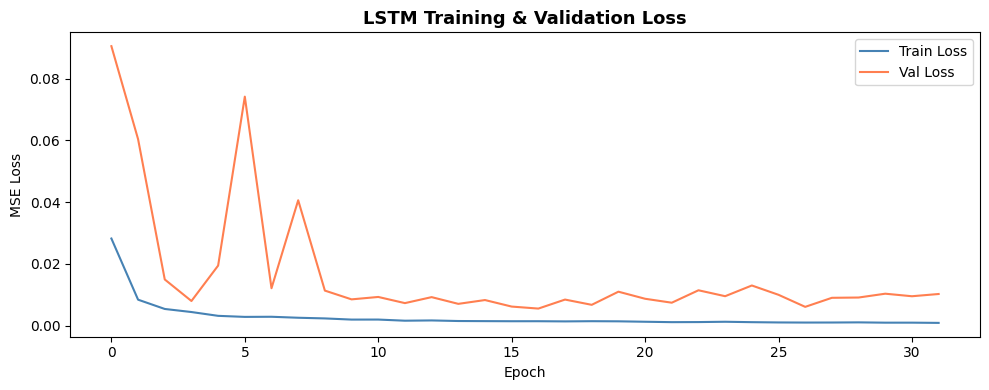

In [ ]:
# ── LSTM Evaluation ──────────────────────────────────────────
y_pred_scaled = lstm_model.predict(X_te, verbose=0).flatten()
y_pred_price  = price_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true_price  = price_scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_true_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
r2   = r2_score(y_true_price, y_pred_price)

# Directional accuracy from LSTM regression
lstm_dir_acc = np.mean(np.sign(np.diff(y_true_price)) == np.sign(np.diff(y_pred_price)))

print(f"📊 LSTM Evaluation — {STOCK}")
print(f"   MAE : ₹{mae:,.2f}  (average absolute price error)")
print(f"   RMSE: ₹{rmse:,.2f}")
print(f"   R²  : {r2:.4f}  (1.0 = perfect fit)")
print(f"   Directional Accuracy: {lstm_dir_acc:.2%}")

# ── Plot Actual vs Predicted ──────────────────────────────────
# The dates for y_te (and y_true_price) effectively start at model_df index LOOK_BACK + split
test_dates = model_df['date'].iloc[LOOK_BACK + split:].values

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_dates, y_true_price, label='Actual Price', color='royalblue', linewidth=1.5)
ax.plot(test_dates, y_pred_price, label='LSTM Predicted', color='orangered',
        linewidth=1.2, linestyle='--', alpha=0.85)
ax.set_title(f"LSTM: Actual vs Predicted Close Price — {STOCK}", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"lstm_predictions_{STOCK}.png", dpi=150)
plt.show()

# Training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='coral')
ax.set_title("LSTM Training & Validation Loss", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()


### Cell 4.5 — Model Comparison Summary
We compare our two models side by side.  
Each approach has trade-offs: XGBoost is faster and more interpretable;  
LSTM captures temporal dependencies but is slower and needs more data.


In [ ]:
comparison = pd.DataFrame({
    'Model': ['XGBoost Classifier', 'LSTM Regressor'],
    'Task': ['Direction (Up/Down)', 'Next-day Price'],
    'Primary Metric': [f'{acc:.2%} Accuracy', f'INR {mae:,.2f} MAE'],
    'Secondary Metric': ['Precision / Recall', f'R2 = {r2:.4f}'],
    'Training Speed': ['Fast (~seconds)', 'Slow (~minutes)'],
    'Interpretability': ['High (feature importances)', 'Low (black box)'],
    'Best For': ['Signal generation', 'Price trajectory']
})
print("Model Comparison:")
display(comparison)
print("Key Takeaway:")
print("  XGBoost: use to generate BUY/SELL signals (direction)")
print("  LSTM   : use to visualize expected price trajectory")
print("  Neither model should be used for real trading without risk management!")


Model Comparison:


,Model,Task,Primary Metric,Secondary Metric,Training Speed,Interpretability,Best For
0,XGBoost Classifier,Direction (Up/Down),52.32% Accuracy,Precision / Recall,Fast (~seconds),High (feature importances),Signal generation
1,LSTM Regressor,Next-day Price,INR 161.13 MAE,R2 = 0.7442,Slow (~minutes),Low (black box),Price trajectory


Key Takeaway:
  XGBoost: use to generate BUY/SELL signals (direction)
  LSTM   : use to visualize expected price trajectory
  Neither model should be used for real trading without risk management!


---
## 💼 Section 5: Portfolio Construction Module

### Cell 5.1 — Modern Portfolio Theory (MPT) Background
Harry Markowitz's **Modern Portfolio Theory** (1952) forms the foundation  
of portfolio construction. Core idea: you can reduce risk through diversification  
without sacrificing expected return.

**Key concepts:**
- **Expected Return (μ)**: historical mean annual return per stock
- **Covariance Matrix (Σ)**: how stocks move relative to each other
- **Efficient Frontier**: the set of portfolios with maximum return for a given risk
- **Sharpe Ratio** = (Return - Risk-free rate) / Volatility → maximize this

We use the `PyPortfolioOpt` library to solve this optimization problem.


In [ ]:
# ── Prepare price matrix for portfolio optimization ──────────
# Use last 5 years of data for more relevant estimates
recent_df = df[df['date'] >= '2016-01-01']
prices_pivot = recent_df.pivot_table(index='date', columns='symbol', values='close')
prices_pivot.ffill(inplace=True)   # forward-fill missing trading days
prices_pivot.dropna(axis=1, thresh=int(len(prices_pivot)*0.9), inplace=True)  # keep stocks with 90%+ data
prices_pivot.dropna(inplace=True)

print(f"Portfolio universe: {prices_pivot.shape[1]} stocks, {len(prices_pivot)} trading days")
print(f"Date range: {prices_pivot.index.min().date()} → {prices_pivot.index.max().date()}")
print(f"Stocks available: {list(prices_pivot.columns)}")


Portfolio universe: 49 stocks, 1318 trading days
Date range: 2016-01-01 → 2021-04-30
Stocks available: ['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'INDUSINDBK', 'INFY', 'IOC', 'ITC', 'JSWSTEEL', 'KOTAKBANK', 'LT', 'M&M', 'MARUTI', 'NESTLEIND', 'NTPC', 'ONGC', 'POWERGRID', 'RELIANCE', 'SBIN', 'SHREECEM', 'SUNPHARMA', 'TATAMOTORS', 'TATASTEEL', 'TCS', 'TECHM', 'TITAN', 'ULTRACEMCO', 'UPL', 'VEDL', 'WIPRO', 'ZEEL']


### Cell 5.2 — Define Three Investor Profiles & Optimize
We create three portfolio types:

| Profile | Objective | Risk Tolerance |
|---|---|---|
| **Conservative** | Minimize portfolio variance (risk) | Low |
| **Balanced** | Maximize Sharpe Ratio (best risk/return ratio) | Medium |
| **Aggressive** | Maximize expected return | High |

`PyPortfolioOpt` uses **mean-historical-return** and **sample covariance matrix**  
as inputs to solve the optimization via quadratic programming.


In [ ]:
RISK_FREE_RATE = 0.06   # RBI repo rate ~6% (India benchmark)

# ── Compute inputs ────────────────────────────────────────────
mu    = expected_returns.mean_historical_return(prices_pivot, frequency=252)
Sigma = risk_models.sample_cov(prices_pivot, frequency=252)

def optimize_portfolio(objective, label):
    """
    objective: 'min_volatility', 'max_sharpe', or 'max_return'
    Returns: weights dict, performance metrics
    """
    ef = EfficientFrontier(mu, Sigma, weight_bounds=(0, 0.25))  # max 25% per stock

    if objective == 'min_volatility':
        ef.min_volatility()
    elif objective == 'max_sharpe':
        ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
    elif objective == 'max_return':
        # Aggressive: maximize quadratic utility with high risk aversion lambda=0
        ef.max_quadratic_utility(risk_aversion=0.1)

    weights = ef.clean_weights()            # rounds tiny weights to 0
    perf    = ef.portfolio_performance(verbose=False, risk_free_rate=RISK_FREE_RATE)

    print(f"\n📊 {label} Portfolio:")
    print(f"   Expected Annual Return : {perf[0]:.2%}")
    print(f"   Annual Volatility      : {perf[1]:.2%}")
    print(f"   Sharpe Ratio           : {perf[2]:.3f}")
    return weights, perf

# Run three optimizations
weights_cons, perf_cons = optimize_portfolio('min_volatility', '🔵 Conservative')
weights_bal,  perf_bal  = optimize_portfolio('max_sharpe',     '🟢 Balanced')
weights_agg,  perf_agg  = optimize_portfolio('max_return',     '🔴 Aggressive')

print("\n✅ All three portfolio profiles optimized!")



📊 🔵 Conservative Portfolio:
   Expected Annual Return : 7.50%
   Annual Volatility      : 14.44%
   Sharpe Ratio           : 0.104

📊 🟢 Balanced Portfolio:
   Expected Annual Return : 29.11%
   Annual Volatility      : 21.18%
   Sharpe Ratio           : 1.091

📊 🔴 Aggressive Portfolio:
   Expected Annual Return : 33.33%
   Annual Volatility      : 28.73%
   Sharpe Ratio           : 0.951

✅ All three portfolio profiles optimized!


### Cell 5.3 — Visualize Portfolio Allocations
Pie charts show how capital is split across stocks in each profile.  
Conservative portfolios concentrate in low-volatility stocks;  
aggressive ones bet heavier on high-return (riskier) stocks.


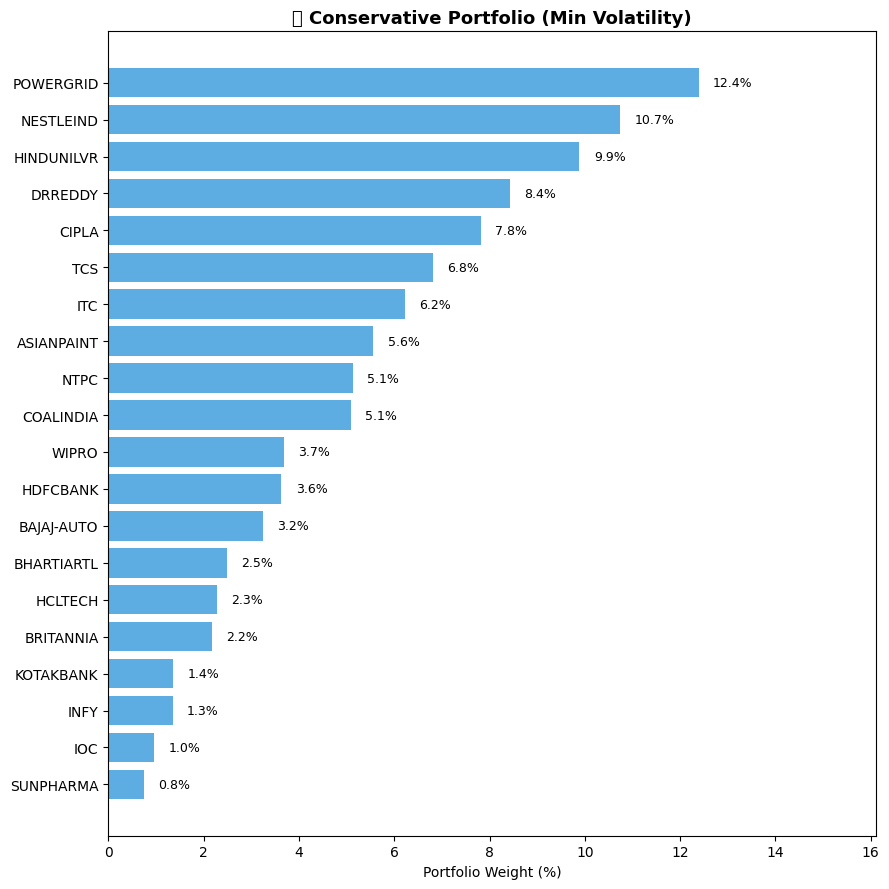

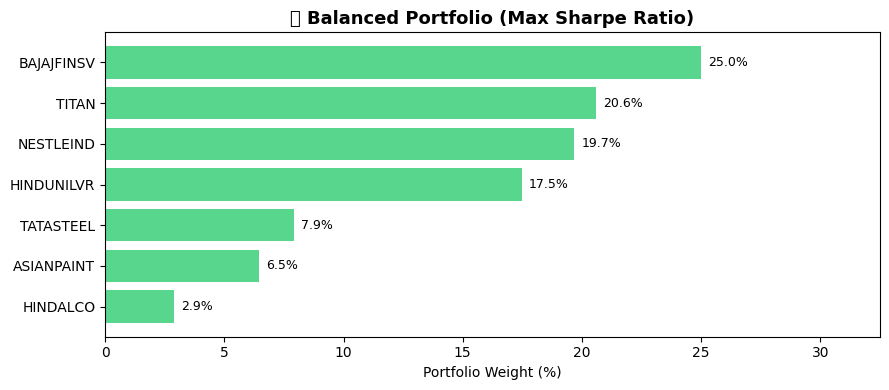

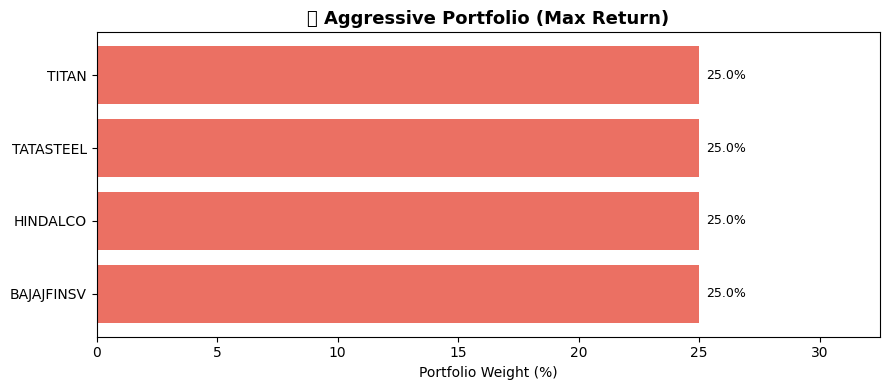

In [ ]:
def plot_portfolio_weights(weights_dict, title, color):
    """Plot top holdings as a horizontal bar chart."""
    weights_clean = {k: v for k, v in weights_dict.items() if v > 0.005}
    weights_s = pd.Series(weights_clean).sort_values()

    fig, ax = plt.subplots(figsize=(9, max(4, len(weights_s) * 0.45)))
    bars = ax.barh(weights_s.index, weights_s.values * 100, color=color, alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Portfolio Weight (%)")
    for bar in bars:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.1f}%", va='center', fontsize=9)
    ax.set_xlim(0, max(weights_s.values) * 130)
    plt.tight_layout()
    plt.savefig(f"portfolio_{title[:4].lower()}.png", dpi=150)
    plt.show()

plot_portfolio_weights(weights_cons, "🔵 Conservative Portfolio (Min Volatility)", "#3498db")
plot_portfolio_weights(weights_bal,  "🟢 Balanced Portfolio (Max Sharpe Ratio)",   "#2ecc71")
plot_portfolio_weights(weights_agg,  "🔴 Aggressive Portfolio (Max Return)",        "#e74c3c")


### Cell 5.4 — Efficient Frontier Plot
The **Efficient Frontier** shows all possible risk/return combinations.  
- Each point = a possible portfolio
- **Blue line** = the efficient frontier (optimal portfolios)
- **Stars** = our three constructed portfolios

Portfolios BELOW the frontier are suboptimal — same risk, less return.


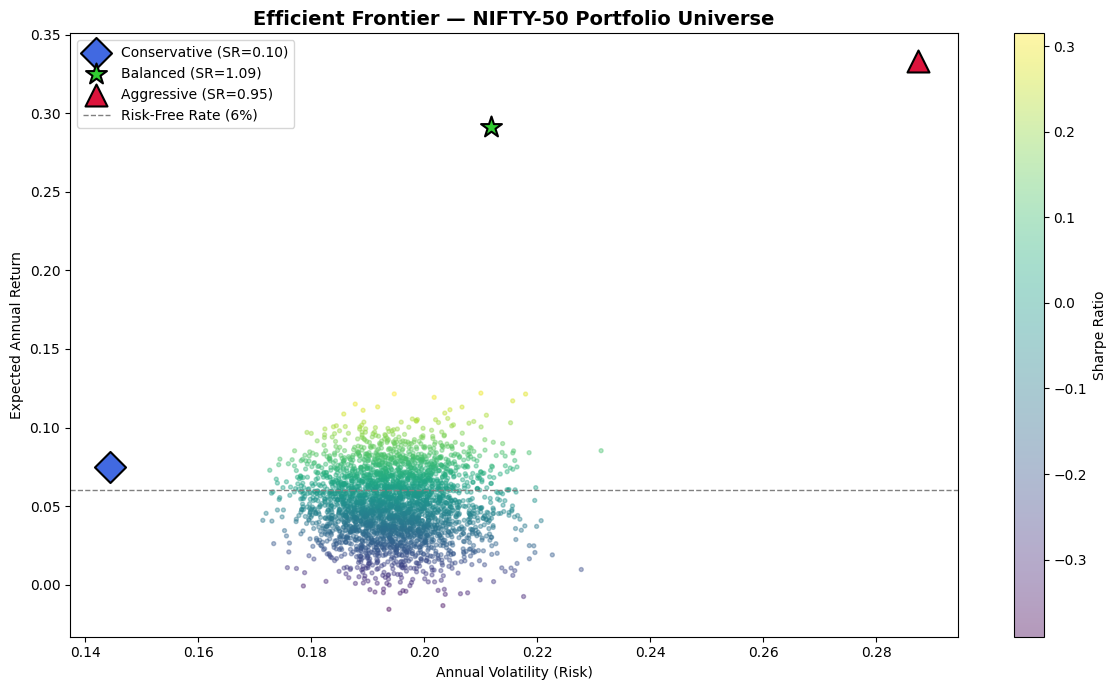

In [ ]:
# Generate random portfolios for Monte Carlo scatter
np.random.seed(42)
n_portfolios = 3000
n_stocks     = len(prices_pivot.columns)
rets_arr, vols_arr, sharpe_arr = [], [], []

for _ in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n_stocks))
    r = float(mu.values @ w)
    v = float(np.sqrt(w @ Sigma.values @ w))
    rets_arr.append(r)
    vols_arr.append(v)
    sharpe_arr.append((r - RISK_FREE_RATE) / v)

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(vols_arr, rets_arr, c=sharpe_arr,
                     cmap='viridis', alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Mark our three portfolios
for weights, perf, label, color, marker in [
    (weights_cons, perf_cons, 'Conservative', 'royalblue',  'D'),
    (weights_bal,  perf_bal,  'Balanced',     'limegreen',  '*'),
    (weights_agg,  perf_agg,  'Aggressive',   'crimson',    '^'),
]:
    ax.scatter(perf[1], perf[0], color=color, s=250, marker=marker,
               edgecolors='black', linewidths=1.5, zorder=5,
               label=f'{label} (SR={perf[2]:.2f})')

ax.set_title("Efficient Frontier — NIFTY-50 Portfolio Universe", fontsize=14, fontweight='bold')
ax.set_xlabel("Annual Volatility (Risk)")
ax.set_ylabel("Expected Annual Return")
ax.axhline(RISK_FREE_RATE, color='gray', linestyle='--', linewidth=1, label=f'Risk-Free Rate ({RISK_FREE_RATE:.0%})')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150)
plt.show()


---
## 🛡️ Section 6: Risk Assessment Module

### Cell 6.1 — Individual Stock Risk Metrics
We compute a comprehensive risk scorecard for each stock:

| Metric | Formula | Interpretation |
|---|---|---|
| **Annualized Return** | μ × 252 | Average yearly gain |
| **Annualized Volatility** | σ × √252 | Yearly price swing |
| **Sharpe Ratio** | (R - Rf) / σ | Return per unit of risk (higher = better) |
| **Sortino Ratio** | (R - Rf) / σ_downside | Like Sharpe but penalizes only downside risk |
| **Max Drawdown** | Max peak-to-trough decline | Worst historical loss from a peak |
| **VaR 95%** | 5th percentile of daily returns | Loss not exceeded 95% of days |
| **Beta** | Cov(stock, market) / Var(market) | Sensitivity to market moves |


In [ ]:
def compute_risk_metrics(returns_series, market_returns=None, rf=RISK_FREE_RATE/252):
    """
    Compute a full risk scorecard for a stock given its daily returns.
    rf = daily risk-free rate (annual / 252)
    """
    r = returns_series.dropna()

    ann_return = r.mean() * 252
    ann_vol    = r.std()  * np.sqrt(252)
    sharpe     = (ann_return - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else np.nan

    # Sortino: only downside deviation
    downside   = r[r < 0].std() * np.sqrt(252)
    sortino    = (ann_return - RISK_FREE_RATE) / downside if downside > 0 else np.nan

    # Max Drawdown: largest peak-to-trough decline
    cum_ret    = (1 + r).cumprod()
    rolling_max= cum_ret.cummax()
    drawdown   = (cum_ret - rolling_max) / rolling_max
    max_dd     = drawdown.min()

    # Value at Risk (95% confidence)
    var_95     = np.percentile(r, 5)   # 5th percentile = worst 5% of days

    # Beta (correlation with market)
    beta = np.nan
    if market_returns is not None:
        aligned = pd.concat([r, market_returns], axis=1).dropna()
        if len(aligned) > 30:
            cov_matrix = np.cov(aligned.iloc[:, 0], aligned.iloc[:, 1])
            beta = cov_matrix[0, 1] / cov_matrix[1, 1]

    return {
        'Ann. Return (%)': round(ann_return * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio': round(sharpe, 3),
        'Sortino Ratio': round(sortino, 3),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'VaR 95% (daily %)': round(var_95 * 100, 2),
        'Beta': round(beta, 3) if not np.isnan(beta) else 'N/A'
    }

# Compute market proxy: equal-weight average of all stock returns
market_ret = returns_wide.mean(axis=1)

# Compute for all stocks
risk_records = {}
for symbol in returns_wide.columns:
    risk_records[symbol] = compute_risk_metrics(returns_wide[symbol], market_ret)

risk_df = pd.DataFrame(risk_records).T
risk_df = risk_df.apply(pd.to_numeric, errors='coerce')
risk_df.sort_values('Sharpe Ratio', ascending=False, inplace=True)

print("🏆 Top 10 Stocks by Sharpe Ratio (Best Risk-Adjusted Return):")
display(risk_df.head(10))
print("\n⚠️  Bottom 10 Stocks (Worst Risk-Adjusted Return):")
display(risk_df.tail(10))

# Save full risk table
risk_df.to_csv("nifty50_risk_scorecard.csv")
print("\n✅ Full risk scorecard saved to nifty50_risk_scorecard.csv")


🏆 Top 10 Stocks by Sharpe Ratio (Best Risk-Adjusted Return):


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),VaR 95% (daily %),Beta
BHARTI,58.77,44.75,1.179,2.114,-54.19,-3.77,0.936
UTIBANK,53.36,49.98,0.948,1.514,-59.02,-4.47,1.125
SHREECEM,38.23,38.97,0.827,1.297,-79.97,-3.54,0.890
BAJFINANCE,39.10,46.68,0.709,0.698,-93.28,-3.28,1.251
BAJAJFINSV,32.31,40.09,0.656,0.923,-86.79,-3.49,1.024
BAJAUTOFIN,39.12,50.58,0.655,1.030,-91.80,-4.35,0.780
MARUTI,26.84,34.48,0.604,0.898,-61.34,-3.17,1.033
EICHERMOT,34.70,48.04,0.598,0.742,-93.82,-3.73,0.949
HINDUNILVR,21.84,26.75,0.592,0.950,-26.78,-2.37,0.542
NESTLEIND,19.79,24.23,0.569,0.891,-32.40,-2.15,0.484



⚠️  Bottom 10 Stocks (Worst Risk-Adjusted Return):


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),VaR 95% (daily %),Beta
WIPRO,5.49,48.59,-0.011,-0.011,-98.31,-3.89,1.096
IOC,4.78,42.10,-0.029,-0.032,-91.00,-3.37,0.881
INFOSYSTCH,3.52,53.35,-0.046,-0.047,-93.46,-4.05,1.001
INFY,2.34,40.03,-0.091,-0.081,-87.94,-2.35,0.694
HINDALC0,0.90,48.58,-0.105,-0.097,-92.21,-3.50,0.812
ZEETELE,-2.03,63.66,-0.126,-0.179,-95.96,-6.18,1.441
HINDLEVER,-8.27,47.92,-0.298,-0.282,-96.62,-3.46,0.810
MUNDRAPORT,-14.91,65.36,-0.320,-0.331,-91.23,-4.92,1.151
COALINDIA,-4.73,29.83,-0.360,-0.535,-75.07,-2.92,0.796
JSWSTL,-50.80,34.31,-1.656,-2.833,-36.43,-3.40,1.265



✅ Full risk scorecard saved to nifty50_risk_scorecard.csv


### Cell 6.2 — Portfolio-level Risk Analysis
Now we compute risk metrics at the **portfolio level** for each  
of our three investor profiles. This shows how well diversification  
reduced risk compared to holding individual stocks.


📊 Portfolio Risk Comparison:


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),VaR 95% (daily %),Beta
Conservative,10.22,14.14,0.298,0.379,-32.67,-1.3,N/A
Balanced,18.21,18.68,0.653,0.845,-51.29,-1.61,N/A
Aggressive,18.2,26.94,0.453,0.592,-73.54,-2.48,N/A


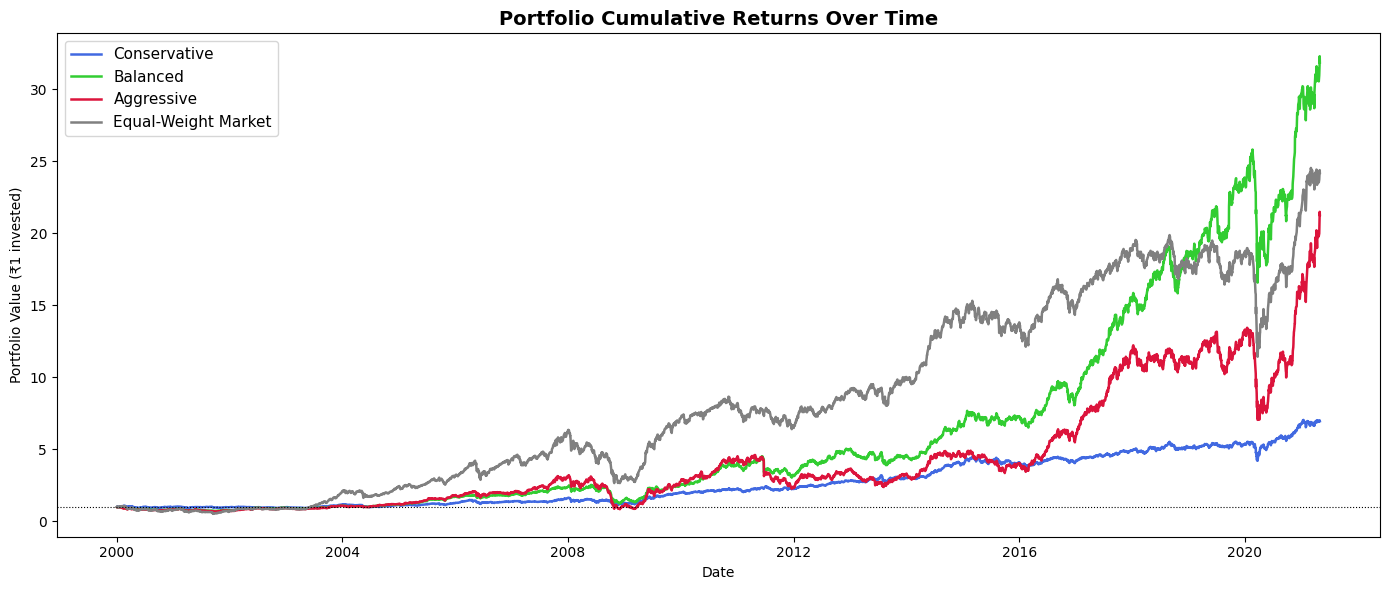

In [ ]:
def portfolio_daily_returns(weights_dict, returns_df):
    """Compute the weighted daily return of a portfolio."""
    stocks_in_portfolio = [s for s in weights_dict if weights_dict[s] > 0.001]
    available = [s for s in stocks_in_portfolio if s in returns_df.columns]
    w_array = np.array([weights_dict[s] for s in available])
    w_array /= w_array.sum()   # renormalize (in case some stocks dropped)
    return (returns_df[available] * w_array).sum(axis=1)

port_ret_cons = portfolio_daily_returns(weights_cons, returns_wide)
port_ret_bal  = portfolio_daily_returns(weights_bal,  returns_wide)
port_ret_agg  = portfolio_daily_returns(weights_agg,  returns_wide)

portfolio_risk = pd.DataFrame({
    'Conservative': compute_risk_metrics(port_ret_cons),
    'Balanced':     compute_risk_metrics(port_ret_bal),
    'Aggressive':   compute_risk_metrics(port_ret_agg),
}).T

print("📊 Portfolio Risk Comparison:")
display(portfolio_risk)

# ── Cumulative return chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for ret_series, label, color in [
    (port_ret_cons, 'Conservative', 'royalblue'),
    (port_ret_bal,  'Balanced',     'limegreen'),
    (port_ret_agg,  'Aggressive',   'crimson'),
    (market_ret,    'Equal-Weight Market', 'gray')
]:
    cum = (1 + ret_series).cumprod()
    ax.plot(cum.index, cum.values, label=label, linewidth=1.8, color=color)

ax.set_title("Portfolio Cumulative Returns Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (₹1 invested)")
ax.legend(fontsize=11)
ax.axhline(1, color='black', linewidth=0.8, linestyle=':')
plt.tight_layout()
plt.savefig("portfolio_cumulative_returns.png", dpi=150)
plt.show()


### Cell 6.3 — Drawdown Analysis
A **drawdown chart** shows how far the portfolio dropped from its  
previous peak at any point in time. This is extremely important  
for risk management — it tells you the worst pain an investor  
would have experienced.


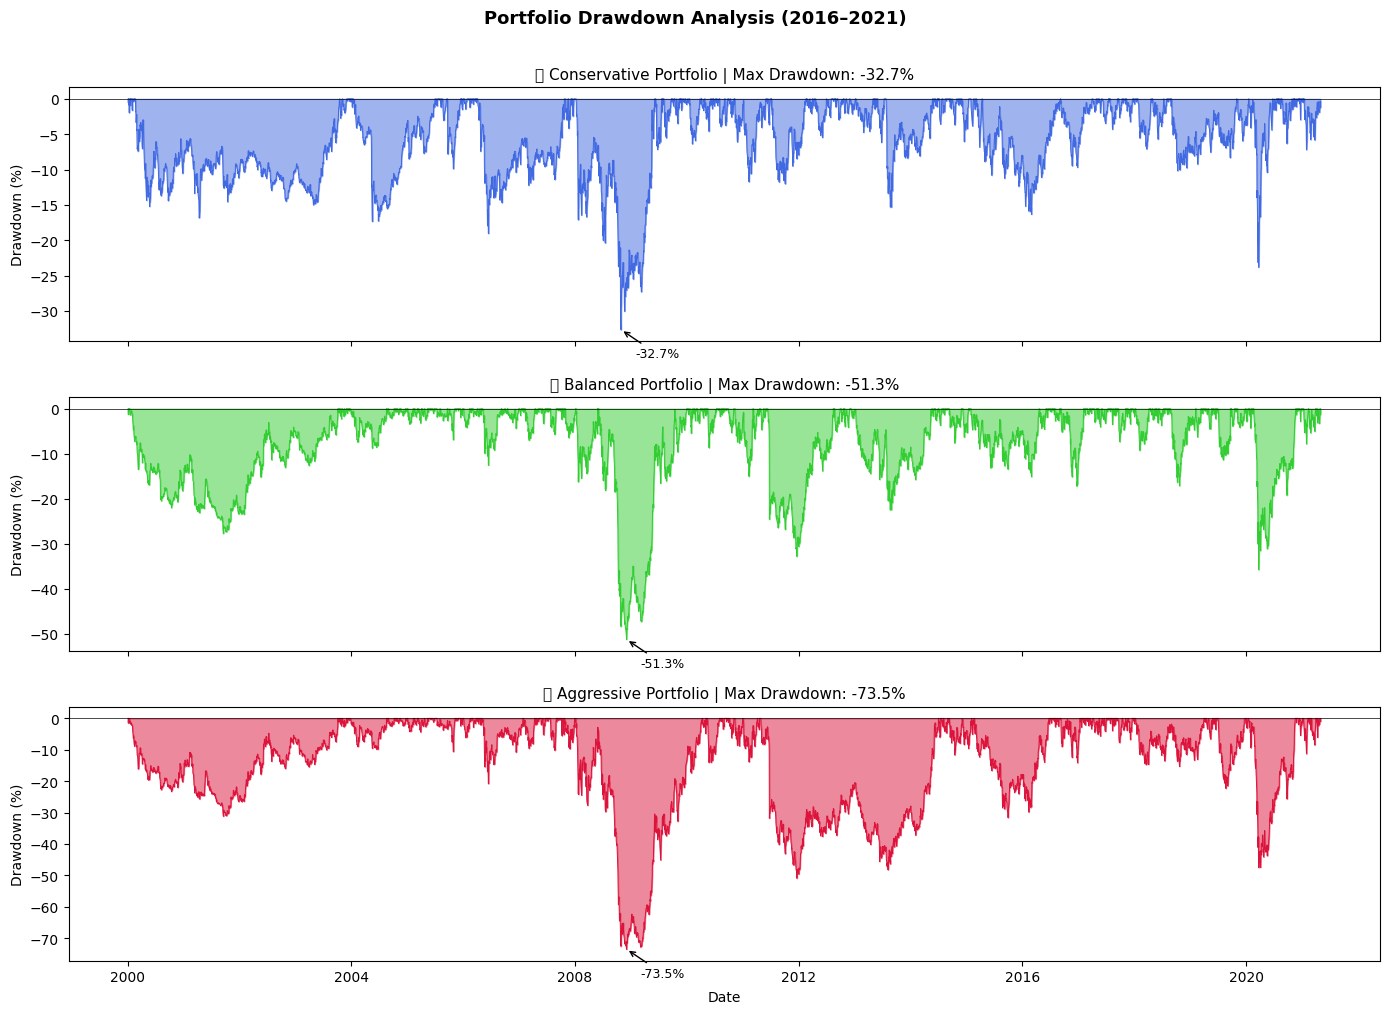

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

configs = [
    (port_ret_cons, '🔵 Conservative Portfolio', 'royalblue'),
    (port_ret_bal,  '🟢 Balanced Portfolio',     'limegreen'),
    (port_ret_agg,  '🔴 Aggressive Portfolio',   'crimson'),
]

for ax, (ret_s, label, color) in zip(axes, configs):
    cum = (1 + ret_s).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max * 100

    ax.fill_between(drawdown.index, drawdown.values, 0,
                    color=color, alpha=0.5, label=label)
    ax.plot(drawdown.index, drawdown.values, color=color, linewidth=0.7)
    ax.set_ylabel("Drawdown (%)")
    ax.set_title(f"{label} | Max Drawdown: {drawdown.min():.1f}%", fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5)

    # Annotate worst drawdown
    worst_idx = drawdown.idxmin()
    ax.annotate(f"{drawdown.min():.1f}%", xy=(worst_idx, drawdown.min()),
                xytext=(10, -20), textcoords='offset points',
                fontsize=9, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

axes[-1].set_xlabel("Date")
plt.suptitle("Portfolio Drawdown Analysis (2016–2021)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("drawdown_analysis.png", dpi=150)
plt.show()


---
## 🧠 Section 7: Explainability with SHAP

### Cell 7.1 — Why Explainability Matters
Black-box ML models give predictions without explanations. In finance,  
regulators and investors need to understand **WHY** a recommendation was made.

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution  
score for every individual prediction. It answers:
- *"Why did the model predict UP for TCS on this date?"*
- *"Which indicators most influenced this recommendation?"*

This is the **Explainability** section of the rubric.


⚙️  Computing SHAP values (may take ~30 seconds)...

📊 SHAP Beeswarm Plot — Global Feature Importance:


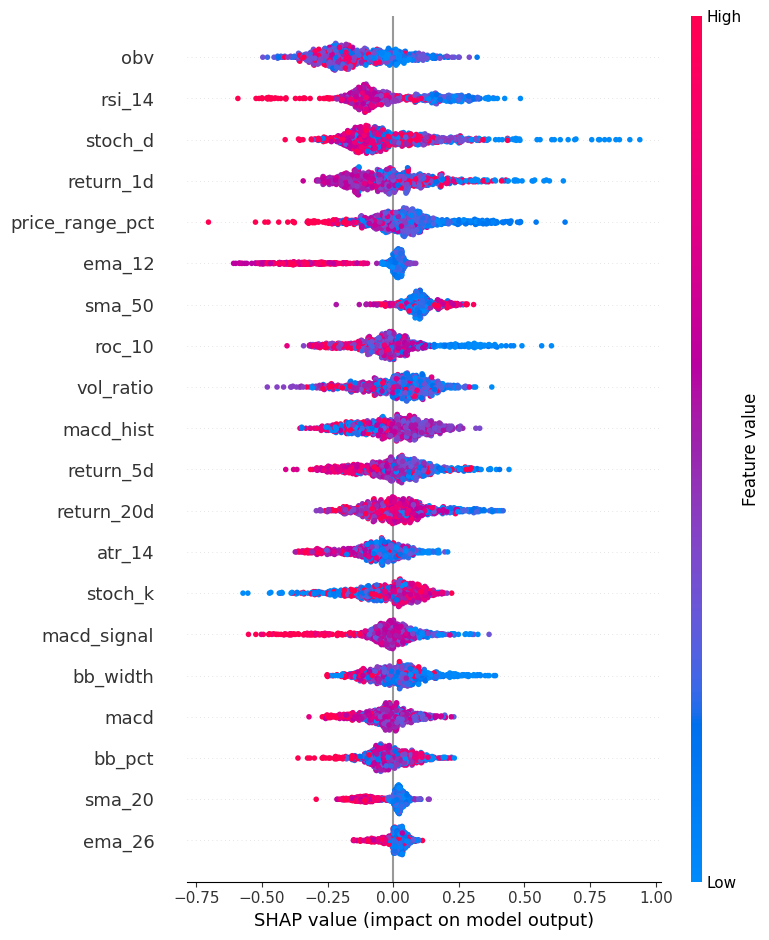

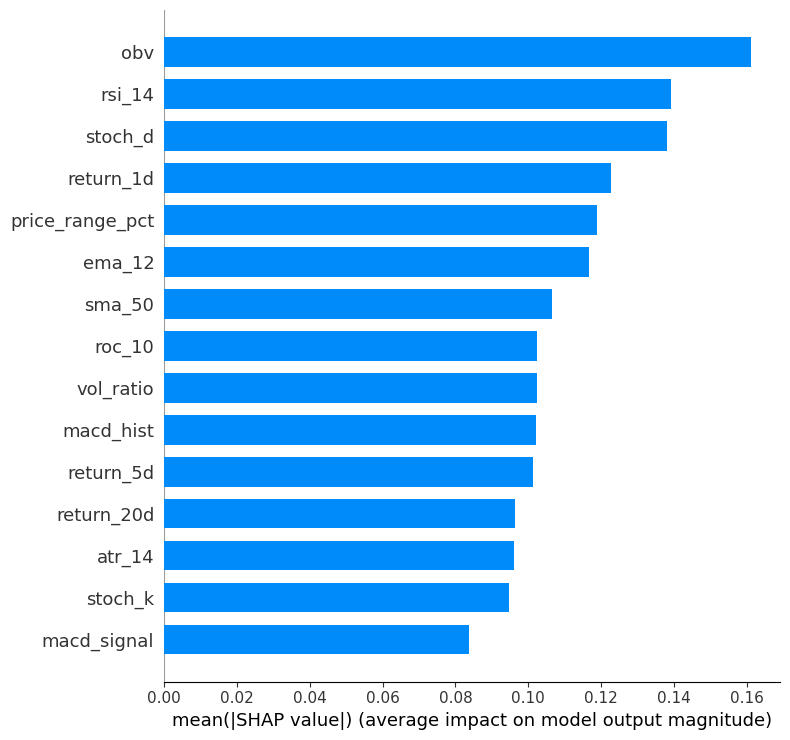

In [ ]:
# SHAP on the XGBoost classifier we trained in Section 4
print("⚙️  Computing SHAP values (may take ~30 seconds)...")

explainer  = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_s)

# If binary classification, shap_values is a list [class0, class1]
if isinstance(shap_values, list):
    sv = shap_values[1]   # use class 1 (UP) SHAP values
else:
    sv = shap_values

# ── Global Feature Importance (Beeswarm plot) ─────────────────
print("\n📊 SHAP Beeswarm Plot — Global Feature Importance:")
shap.summary_plot(sv, X_test_s, feature_names=FEATURE_COLS,
                  plot_type="dot", max_display=20, show=True)

# ── Bar chart version ─────────────────────────────────────────
shap.summary_plot(sv, X_test_s, feature_names=FEATURE_COLS,
                  plot_type="bar", max_display=15, show=True)



🔍 Local explanation for test sample 10:
   True direction : UP ↑
   Model prediction: DOWN ↓



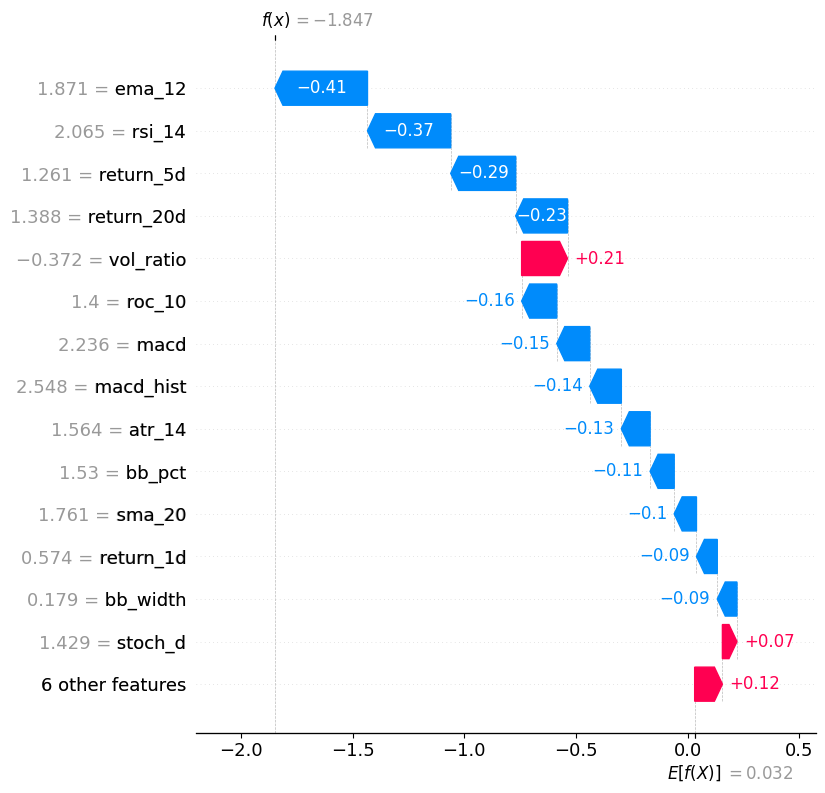


📌 How to read: Red bars push prediction HIGHER (towards UP), blue bars push LOWER.


In [ ]:
# ── Local Explanation: Why did the model predict UP for Day X? ──
sample_idx = 10   # pick any test sample index

shap.initjs()  # for waterfall plots in notebook
print(f"\n🔍 Local explanation for test sample {sample_idx}:")
print(f"   True direction : {'UP ↑' if y_test_c[sample_idx] == 1 else 'DOWN ↓'}")
print(f"   Model prediction: {'UP ↑' if y_pred_xgb[sample_idx] == 1 else 'DOWN ↓'}\n")

# Waterfall plot: shows how each feature pushed prediction above/below baseline
shap_exp = shap.Explanation(
    values     = sv[sample_idx],
    base_values= explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                 else explainer.expected_value,
    data       = X_test_s[sample_idx],
    feature_names=FEATURE_COLS
)
shap.plots.waterfall(shap_exp, max_display=15)

print("\n How to read: Red bars push prediction HIGHER (towards UP), blue bars push LOWER.")


---
## 📚 References
- [NIFTY-50 Dataset (Kaggle)](https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data/data)
- [PyPortfolioOpt Documentation](https://pyportfolioopt.readthedocs.io/)
- [SHAP Documentation](https://shap.readthedocs.io/)
- [TA-lib / ta Python library](https://technical-analysis-library-in-python.readthedocs.io/)
- Markowitz, H. (1952). Portfolio Selection. *Journal of Finance*, 7(1), 77–91.
- Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation*, 9(8).
